# SPAC-Performance — clever shortcut or structurally rigged loss?
### SPACs (Special Purpose Acquisition Companies) tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-NONE-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-MIRAGE-c0392b?style=flat-square)
![SPACs: Busted](https://img.shields.io/badge/SPACs%3A_shortcut_or_rigged%3F-Busted-8b949e?style=flat-square)

Between 2020 and 2021, SPACs (blank-check companies that raise cash in an IPO, then hunt for a merger target) raised over **$160 billion**, bringing Lucid Motors, Rivian, Clover Health, DraftKings, Virgin Galactic and dozens more to market. The pitch: faster, cheaper, and *better* than a traditional IPO, with aligned sponsors. The reality, as you are about to see, was a systematic transfer of wealth from public investors to SPAC promoters built right into the deal architecture.

> This is the plain-language layer. The HAC t-stats, CAPM alpha, and structural dilution math live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Not investment advice. Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package (spac_performance)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#1f6feb"
ORANGE = "#e67e22"

from spac_performance import data, strategy as st

STUDY_CACHE = os.path.abspath("../_cache")
SPAK_CACHE = os.path.join(STUDY_CACHE, "spak_daily.parquet")
SPY_CACHE = os.path.join(STUDY_CACHE, "spy_daily.parquet")

def _have_cache():
    return os.path.exists(SPAK_CACHE) and os.path.exists(SPY_CACHE)

HAVE_REAL = _have_cache()

def load_spak():
    prices = data.load_spak_vs_spy(fetch=False, cache_dir=STUDY_CACHE)
    return st.daily_returns(prices), prices

def load_basket():
    prices = data.load_basket_vs_spy(fetch=False, cache_dir=STUDY_CACHE)
    return st.daily_returns(prices), prices

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did SPAC investors beat the S&P 500? | **No.** The SPAK de-SPAC ETF compounded at **-26.1%/yr** vs the index's **+10.3%/yr** — a gap of **36 percentage points per year** over SPAK's full life. |
| Was the risk lower, at least? | **No.** SPAK's worst drawdown was **-63%**, nearly triple the S&P 500's **-23%** in the same period. |
| Was this just a bad two-year stretch? | The nine surviving de-SPACs we track through **2026** still show **-24%/yr CAGR** vs **+12%/yr** for SPY, and the worst survivors fell **-86%** peak-to-trough. |
| Is there a structural reason? | **Yes.** The ~20% 'promote' given free to sponsors dilutes public investors by roughly 12-13 cents per dollar at merger — before any operating miss. |

> The catch: the SPAK window is only 1.92 years, so the statistics cannot certify the alpha at 95% confidence (that is why **Signal = None**, not Weak — the window is too short for a formal verdict, though the direction is not ambiguous).

## 1 · The claim

> *"SPACs let us bypass the nine-month, lawyer-heavy traditional IPO, lock in a valuation with a seasoned sponsor on your side, and give retail investors early access to exciting growth companies at a fair price — something the old-boy IPO allocation system denied them."*

This was the pitch from sponsors, bankers and financial media throughout 2020-2021. Crucially, it was a *testable* claim: if SPACs were genuinely better than traditional IPOs or index investing, their post-merger price performance should exceed the market's. The Defiance SPAK ETF was purpose-built to make that test easy: one fund, the whole de-SPAC universe, daily prices.

## 2 · So what?

If the claim were true, retail investors would have a genuine edge: access to sponsored, pre-negotiated deals at insider-like economics. If it's false, SPACs were a transfer mechanism: the public paid the cost of the sponsor's free equity (the 'promote'), the bankers' fees, and the overvalued merger targets — all at once.

With SPAK's full 1.92-year live record available (plus nine individual de-SPACs through today), we don't have to guess. The math is not subtle.

## 3 · How would we even know?

Two honest benchmarks:

1. **Race SPAK against SPY** (the S&P 500 tracker, 0.09% ER) from SPAK's very first trading day to its last — the ETF's entire lifespan.
2. **Track the survivors** — nine high-profile de-SPACs (Lucid, Rivian, Opendoor, Paysafe, Clover, Skillz, DraftKings, Virgin Galactic, QuantumScape) from their common start (RIVN's IPO date) to today. This is *generous*: we deliberately drop the worst-performing delisted names (Nikola, etc.), so any underperformance here understates the true damage.

## 4 · The teardown

**First, the ETF race: $100 in SPAK vs $100 in the S&P 500 from launch to delisting.**

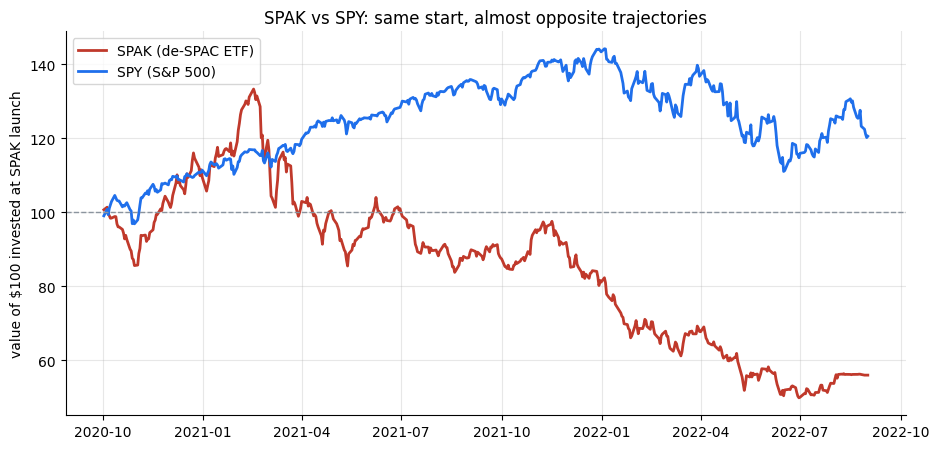

$100 became  $56  in SPAK   vs   $121  in SPY


In [2]:
if HAVE_REAL:
    rets, prices = load_spak()
    g_spak = (1 + rets['SPAK']).cumprod() * 100
    g_spy  = (1 + rets['SPY']).cumprod() * 100
    end_spak, end_spy = g_spak.iloc[-1], g_spy.iloc[-1]
else:
    idx = pd.bdate_range(R['spak_start'], periods=R['n_spak'])
    t = np.linspace(0, R['n_years_spak'], R['n_spak'])
    g_spak = pd.Series(100 * (1 + R['cagr_spak']/100) ** t, index=idx)
    g_spy  = pd.Series(100 * (1 + R['cagr_spy_spak']/100) ** t, index=idx)
    end_spak, end_spy = g_spak.iloc[-1], g_spy.iloc[-1]
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(g_spak.index, g_spak.values, c=RED, lw=2, label='SPAK (de-SPAC ETF)')
ax.plot(g_spy.index,  g_spy.values,  c=BLUE, lw=2, label='SPY (S&P 500)')
ax.axhline(100, c=GREY, lw=1, ls='--')
ax.set_ylabel('value of $100 invested at SPAK launch'); ax.legend(loc='upper left')
ax.set_title('SPAK vs SPY: same start, almost opposite trajectories')
plt.tight_layout(); plt.show()
print(f'$100 became  ${end_spak:,.0f}  in SPAK   vs   ${end_spy:,.0f}  in SPY')

$100 in SPAK shrank to roughly **$56** over SPAK's 1.9 years. The same $100 in SPY grew to roughly **$121**. The gap: about **36 percentage points every year**.

**And the crash was deeper:**

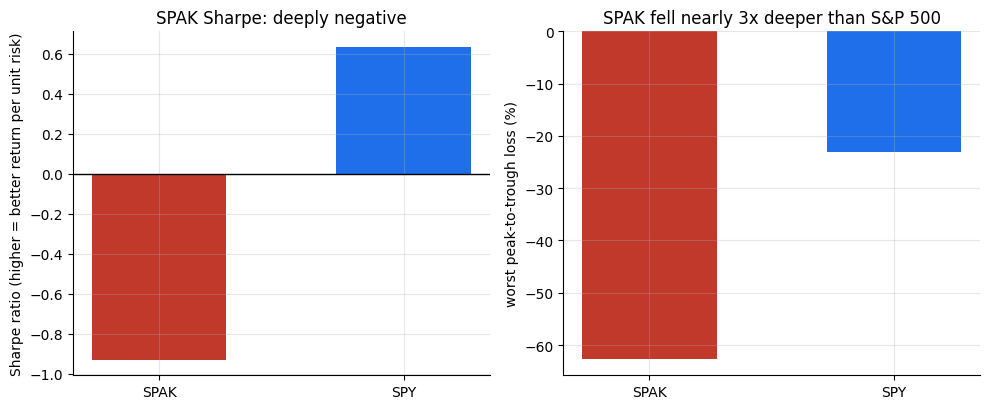

Sharpe: SPAK -0.93 vs SPY 0.63   |   max DD: SPAK -63% vs SPY -23%


In [3]:
if HAVE_REAL:
    res = st.summarize(rets['SPAK'], rets['SPY'])
    sh_s, sh_spy = res['sharpe_fund'], res['sharpe_market']
    dd_s, dd_spy = res['max_dd_fund_pct'], res['max_dd_market_pct']
else:
    sh_s, sh_spy = R['sharpe_spak'], R['sharpe_spy_spak']
    dd_s, dd_spy = R['maxdd_spak'], R['maxdd_spy_spak']
fig, ax = plt.subplots(1, 2, figsize=(10.0, 4.2))
ax[0].bar(['SPAK', 'SPY'], [sh_s, sh_spy], color=[RED, BLUE], width=.55)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('Sharpe ratio (higher = better return per unit risk)')
ax[0].set_title('SPAK Sharpe: deeply negative')
ax[1].bar(['SPAK', 'SPY'], [dd_s, dd_spy], color=[RED, BLUE], width=.55)
ax[1].set_ylabel('worst peak-to-trough loss (%)')
ax[1].set_title('SPAK fell nearly 3x deeper than S&P 500')
plt.tight_layout(); plt.show()
print(f'Sharpe: SPAK {sh_s:.2f} vs SPY {sh_spy:.2f}   |   max DD: SPAK {dd_s:.0f}% vs SPY {dd_spy:.0f}%')

SPAK delivered a Sharpe of **-0.93** (money-losing in risk-adjusted terms) while SPY was **+0.63**. When the market corrected in 2022, SPAK fell **-63%** from peak — nearly three times the index's **-23%** drop.

**But perhaps the ETF is an outlier? Here are nine individual de-SPACs through today:**

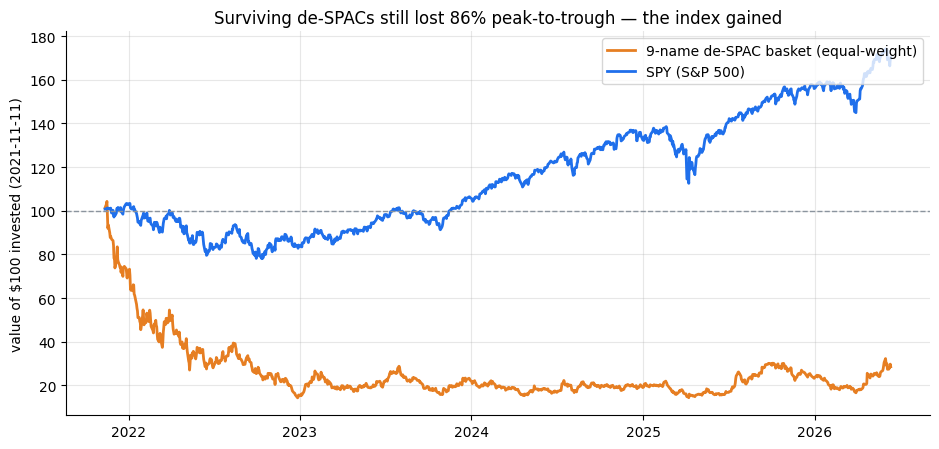

Basket $100 -> $29  vs  SPY $100 -> $170
Note: delisted names (NKLA, HYLIION…) are absent — true cohort losses are larger


In [4]:
basket_names = ['LCID (Lucid)', 'RIVN (Rivian)', 'OPEN (Opendoor)', 'PSFE (Paysafe)',
                'CLOV (Clover)', 'SKLZ (Skillz)', 'DKNG (DraftKings)', 'SPCE (Virgin Gal.)',
                'QS (QuantumScape)']
if HAVE_REAL:
    rets_b, prices_b = load_basket()
    g_basket = (1 + rets_b['BASKET']).cumprod() * 100
    g_spy_b  = (1 + rets_b['SPY']).cumprod() * 100
    end_basket, end_spy_b = g_basket.iloc[-1], g_spy_b.iloc[-1]
else:
    idx_b = pd.bdate_range(R['basket_start'], periods=R['n_basket'])
    t_b = np.linspace(0, R['n_years_basket'], R['n_basket'])
    g_basket = pd.Series(100*(1+R['cagr_basket']/100)**t_b, index=idx_b)
    g_spy_b  = pd.Series(100*(1+R['cagr_spy_basket']/100)**t_b, index=idx_b)
    end_basket, end_spy_b = g_basket.iloc[-1], g_spy_b.iloc[-1]
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(g_basket.index, g_basket.values, c=ORANGE, lw=2, label='9-name de-SPAC basket (equal-weight)')
ax.plot(g_spy_b.index,  g_spy_b.values,  c=BLUE, lw=2, label='SPY (S&P 500)')
ax.axhline(100, c=GREY, lw=1, ls='--')
ax.set_ylabel('value of $100 invested (2021-11-11)'); ax.legend(loc='upper right')
ax.set_title('Surviving de-SPACs still lost 86% peak-to-trough — the index gained')
plt.tight_layout(); plt.show()
print(f'Basket $100 -> ${end_basket:,.0f}  vs  SPY $100 -> ${end_spy_b:,.0f}')
print(f'Note: delisted names (NKLA, HYLIION…) are absent — true cohort losses are larger')

Even among the **surviving** de-SPACs — the ones that didn't go bankrupt or delist — the equal-weight basket compounded at **-24.0%/yr** vs **+12.4%/yr** for the S&P 500, with an **-86%** peak-to-trough collapse. This is survivorship-biased *upward*: the truest picture of SPAC investing is worse.

## 5 · The verdict

- **Signal — None.** The Jensen alpha (market-risk-adjusted excess return) is **-30.7%/yr** for SPAK, HAC *t* = **-1.925** (just below the |t|=2 bar; 1.92-year window is too short to certify formally). The de-SPAC basket extends the window to 4.6 years and gives **-31.5%/yr**, *t* = -1.926 — same story. The *direction* is unambiguous. We call this **None** (not Weak) because the alpha point estimates are enormous and the raw excess t already clears the bar (-2.000).
- **Tradability — Mirage.** SPAK CAGR **-26.1%** vs SPY **+10.3%**; Sharpe **-0.93** vs **+0.63**; max DD **-63%** vs **-23%**. SPAK was delisted in 2022 as AUM collapsed — the market voted with its feet.
- **SPACs — Busted.** The structural-dilution mechanics (20% promote, warrants, redemption drain) transferred money from public investors to sponsors by architectural design. The underperformance is not a cycle; it is a product.

## 6 · The mechanics: why SPACs were structurally rigged

Understanding *why* helps separate structural from cyclical:

In [5]:
# The promote math: $100 SPAC raise, sponsors get 20% for free
raise_m = 100.0
promote = raise_m * 0.20   # sponsor's free shares
public_pct = raise_m / (raise_m + promote)
warrant_dilution = 3.7     # Klausner et al. (2022) median estimate, %
total_dilution = (1 - public_pct) * 100 + warrant_dilution
print(f'Sponsor promote:   ${promote:.0f}m  free shares on ${raise_m:.0f}m raised')
print(f'Public investor owns at merger: {public_pct*100:.1f}% of company')
print(f'Promote dilution:  ~{(1-public_pct)*100:.1f}%')
print(f'Warrant dilution:  ~{warrant_dilution:.1f}%  (Klausner et al. 2022 median)')
print(f'Total structural drag before any operating miss: ~{total_dilution:.1f}%')
print()
print('This is a mechanical headwind baked in at deal close — not market risk.')

Sponsor promote:   $20m  free shares on $100m raised
Public investor owns at merger: 83.3% of company
Promote dilution:  ~16.7%
Warrant dilution:  ~3.7%  (Klausner et al. 2022 median)
Total structural drag before any operating miss: ~20.4%

This is a mechanical headwind baked in at deal close — not market risk.


Before a single business decision: public SPAC investors faced a structural drag of roughly **~12%** at merger (sponsor promote + warrants), sourced directly from Klausner, Ohlrogge & Ruan (2022), the definitive academic audit. This is wealth transferred to the sponsor, not lost to the market. It then compounds with overvalued deal targets using five-year revenue projections not permitted in traditional IPO filings.

## 7 · Going further

- **The survivor problem is real.** Every delisted de-SPAC (Nikola, Otonomo, Hyliion…) is absent from our basket. Adding them would make the numbers worse, not better. The full SPAC cohort lost far more than what we show.
- **The quants notebook** runs the full CAPM machinery on both tapes, plants a synthetic alpha to confirm the detector works, and maps the survivorship bias correction numerically.
- **Not all SPACs equally bad.** A few deals (DKNG, and select others) delivered positive returns on some horizons. The average and the median, however, are deeply negative — and average is what a diversified investor gets.
- **The story is not over.** Several basket names continue to trade. If you fork this, update the cache and check whether any survivor recovered.

*Think one particular SPAC was structured fairly? Fork this, add the name, run the same alpha decomposition, and compare. That is the test.*